# Diamond Price Prediction

---

### **Project Objective**
The goal is to develop a machine learning model that predicts the market value of diamonds. By analyzing historical pricing logic, the model quantifies how specific physical and quality attributes—often referred to as the "4 Cs"—dictate final valuation in a real-world context.

---

### **Feature Overview**

| Feature | Description | Impact on Valuation |
| :--- | :--- | :--- |
| **Carat** | The physical weight (1 carat = 200mg). | **Primary Driver:** Larger diamonds are exponentially rarer and more costly. |
| **Cut** | Quality of the facets (Ideal to Fair). | **Brilliance:** Higher quality cuts reflect light better, increasing sparkle and price. |
| **Color** | Grade from D (Colorless) to J (Visible tint). | **Rarity:** D is the most expensive; J is more common and affordable. |
| **Clarity** | Purity level (Inclusions/Blemishes). | **Purity:** Fewer internal imperfections result in a higher market premium. |
| **x, y, z** | Length, width, and depth in mm. | **Geometry:** Physical dimensions that correlate with weight and shape. |
| **Depth** | Total depth percentage. | **Light Travel:** Crucial for determining how light travels through the stone. |
| **Table** | Width of the top facet. | **Brilliance:** Affects the diamond's overall reflection and "fire." |
| **Price** | **Target Variable** | The final value in USD we aim to predict. |

---

> **Insight:** While carat weight provides the baseline value, the interplay between Cut, Color, and Clarity allows the model to refine predictions for high-end or specialty stones.

In [5]:
# import all nesecarry libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import AdaBoostRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")
print("\nLibraries used:")
print("- pandas: for data manipulation")
print("- sklearn: for ML models and metrics")
print("- matplotlib/seaborn: for visualization")
print("- xgboost: for XGBoost algorithm")

Libraries imported successfully!

Libraries used:
- pandas: for data manipulation
- sklearn: for ML models and metrics
- matplotlib/seaborn: for visualization
- xgboost: for XGBoost algorithm


In [2]:
#Create a requirements.txt file with all the libraries and the versions used in the project
!pip freeze > ../images/requirements.txt

In [ ]:
#UNBOXING OF THE DATASET
df = pd.read_csv('/Users/rajuram/Desktop/Diamond_value_pridcition/Data/Diamond_Price_ Kaggle.csv', index_col=0)
print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,carat,cut,color,clarity,depth,table,price,x,y,z
1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [8]:
print("\nDataset shape:", df.shape)
print("\nDataset info:")
print(df.info())
df.describe()


Dataset shape: (53940, 10)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
Index: 53940 entries, 1 to 53940
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.5+ MB
None


,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [9]:
#Checking for missing values
print("\nMissing values in each column:")
print(df.isnull().sum()) #No missing values found in the dataset (we conclude)

# Check for weird values (x, y, z should not be 0)
print("\nChecking for zero values in dimensions:")
print(f"Zero dimensions: x={sum(df.x==0)}, y={sum(df.y==0)}, z={sum(df.z==0)}") 
# So now we have some zero values in x, y, z columns which is not possible for a diamond.
# now we have 2 option either to drop this data or to impute it with mean or median. Since the number of zero values is very less we can drop this data. 

# Dropping rows with zero dimensions
df = df[(df.x != 0) & (df.y != 0) & (df.z != 0)]
print("\nShape after dropping zero dimension rows:", df.shape)

#verify are there any zeros in x y and z 
print(f"Zero dimensions: x={sum(df.x==0)}, y={sum(df.y==0)}, z={sum(df.z==0)}")  #Perfect we are not left with any zero values in x, y, z columns.


Missing values in each column:


carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

Checking for zero values in dimensions:
Zero dimensions: x=8, y=7, z=20

Shape after dropping zero dimension rows: (53920, 10)
Zero dimensions: x=0, y=0, z=0


In [15]:
#Apply Feature Engineering to create a new feature called by converting 
# color, clarity and cut into numerical values using Label Encoding.
df_featured = df.copy()  # Create a copy of the original dataframe for feature engineering

#Mapping the categorical values to numerical values based on their quality order lowest to highest
cut_mapping = {"Fair": 1, "Good": 2, "Very Good": 3, "Premium": 4, "Ideal": 5} #ideal is 5
color_mapping = {"J": 1, "I": 2, "H": 3, "G": 4, "F": 5, "E": 6, "D": 7}
clarity_map = {"I1": 1, "SI2": 2, "SI1": 3, "VS2": 4, "VS1": 5, "VVS2": 6, "VVS1": 7, "IF": 8}

# Now we will map the categorical values to numerical values in the dataframe
df_featured['cut'] = df_featured['cut'].map(cut_mapping)
df_featured['color'] = df_featured['color'].map(color_mapping)
df_featured['clarity'] = df_featured['clarity'].map(clarity_map)

df_featured.head()  # Display the first few rows of the featured dataframe to verify the changes

,carat,cut,color,clarity,depth,table,price,x,y,z
1,0.23,5,6,2,61.5,55.0,326,3.95,3.98,2.43
2,0.21,4,6,3,59.8,61.0,326,3.89,3.84,2.31
3,0.23,2,6,5,56.9,65.0,327,4.05,4.07,2.31
4,0.29,4,2,4,62.4,58.0,334,4.20,4.23,2.63
5,0.31,2,1,2,63.3,58.0,335,4.34,4.35,2.75


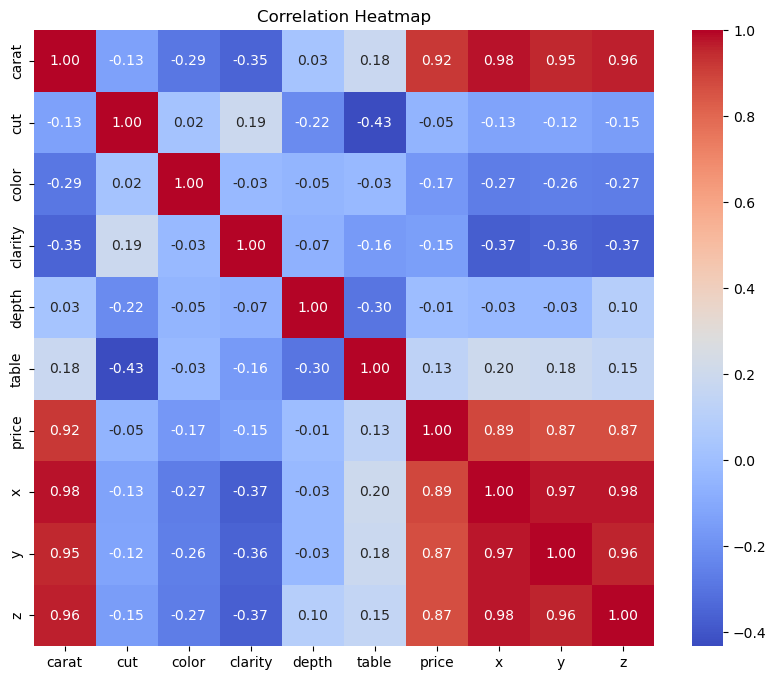

In [17]:
# Now we will create a Heat Map to visualize the correlation between the features
plt.figure(figsize=(10, 8))
sns.heatmap(df_featured.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')       
plt.show()

## Key Insights from the Correlation Heatmap

heatmap illustrates the relationships within the **Diamonds dataset**. The values range from **-1.0** (perfect inverse relationship) to **1.0** (perfect positive relationship).

### 1. The Price Drivers (Strongest Positive Correlations)
The most critical takeaway is the near-perfect relationship between a diamond's physical mass and its market value.

* **Carat & Price (0.92):** This is the dominant relationship. Weight is the primary predictor of cost.
* **Dimensions (x, y, z) & Price (0.87 - 0.89):** As length, width, and depth increase, the price climbs significantly.
* **Dimensions & Carat (0.95 - 0.98):** These variables are almost perfectly correlated because weight is a function of volume.

### 2. The Multicollinearity Cluster
the red block in the bottom-right corner is a major "red flag" for linear modeling:

* **x, y, and z** are so highly correlated with each other (up to **0.98**) that including all of them in a regression model alongside **carat** would likely cause **multicollinearity**. 


### 3. Counter-Intuitive Weak Correlations
Surprisingly, the "Quality" metrics show very low linear correlation with price:

* **Cut (-0.05), Color (-0.17), and Clarity (-0.15):** These show weak negative correlations. 
* **The Reason:** This doesn't mean they don't affect price. Instead, it suggests a "trade-off" in the market—larger diamonds (high carat) often have lower clarity or color grades to keep them at a sellable price point. These features likely have a **non-linear** impact.

### 4. Physical Proportions
* **Table vs. Cut (-0.43):** This is the strongest negative correlation. It suggests that as the "table" (the top flat facet) gets wider, the overall cut grade tends to drop.
* **Depth & Table:** These show very little relationship with price (**-0.01** and **0.13** respectively), indicating they are secondary to the "4 Cs."

---

### Summary Table for Modeling

| Feature Type | Variables | Impact on Price | Modeling Recommendation |
| :--- | :--- | :--- | :--- |
| **Primary** | Carat, x, y, z | Extremely High | Use `carat`; drop `x, y, z` to avoid redundancy. |
| **Secondary** | Cut, Color, Clarity | Low (Linear) | Use as Categorical/Ordinal features. |
| **Proportional** | Depth, Table | Negligible | Often safe to exclude if Carat is present. |

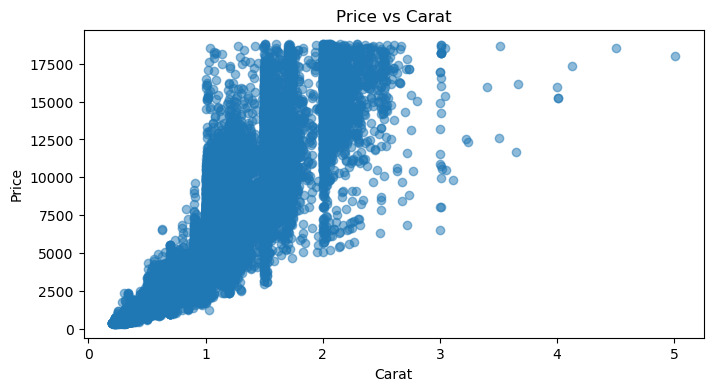

In [24]:
# Price vs Carat (THE most important relationship)
plt.figure(figsize=(8, 4))
plt.scatter(df_featured['carat'], df_featured['price'], alpha=0.5)
plt.title('Price vs Carat')
plt.xlabel('Carat')
plt.ylabel('Price')
plt.show()


# Analysis of Price vs. Carat

---

### **The Fundamental Relationship**
The relationship between **Carat** and **Price** is the most significant correlation in the dataset. As the carat weight increases, the price of the diamond rises following an upward trend. This visual analysis confirms that size is the primary driver of market valuation.

### **Data Distribution and Density**
By examining the scatter distribution, we can identify key characteristics of the dataset:
* **Correlation:** A clear positive trend where higher carat values consistently command higher prices.
* **Data Concentration:** The majority of the observations are concentrated between **0.0 and 3.0 carats**.
* **Sparsity:** Data points become increasingly sparse for diamonds exceeding 3.0 carats, reflecting the natural rarity of larger stones.

---

> **Technical Note:** While the relationship is positive, it is often non-linear. Smaller increases in carat weight typically lead to disproportionately larger jumps in price, especially as the diamond crosses key thresholds (e.g., 1.0ct, 2.0ct).

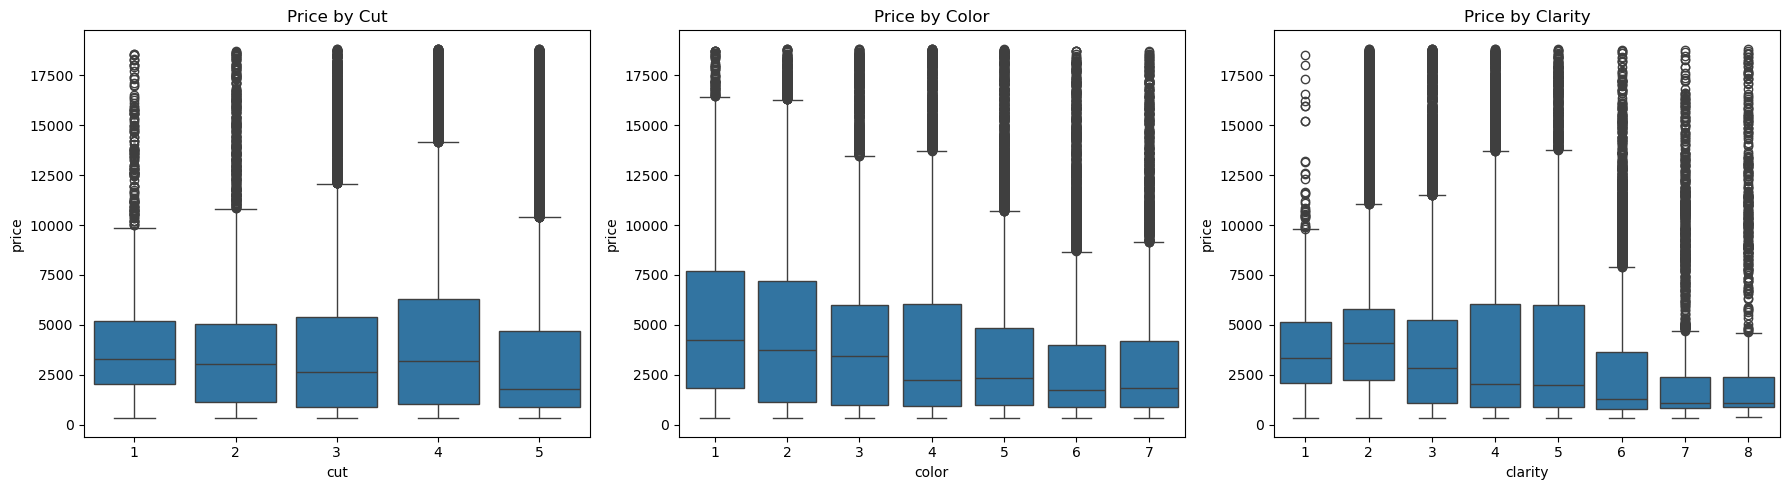

In [25]:
# Price by categorical features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df_featured, x='cut', y='price', ax=axes[0])
axes[0].set_title('Price by Cut')

sns.boxplot(data=df_featured, x='color', y='price', ax=axes[1])
axes[1].set_title('Price by Color')

sns.boxplot(data=df_featured, x='clarity', y='price', ax=axes[2])
axes[2].set_title('Price by Clarity')

plt.tight_layout()
plt.show()


# Categorical Feature Analysis

---

### **Key Observations from Visualizations**

The box plots illustrate the relationship between categorical features (Cut, Color, Clarity) and diamond prices. Below are the primary insights:

#### **1. Price by Cut**
* **Distribution Overlap:** There is a significant overlap in price distributions across all cut qualities (Ideal to Fair).
* **Premium Premium:** Surprisingly, **Premium** and **Fair** cuts show slightly higher median prices compared to **Ideal** cuts. This suggests that "Ideal" cut diamonds in this dataset might be smaller in carat weight, while larger diamonds with lower cut grades are driving higher prices.
* **Outliers:** All categories contain a high density of outliers reaching the $17,500+ range.

#### **2. Price by Color**
* **Inverted Price Trend:** Lower-grade colors (specifically **I** and **J**) show higher median prices and larger interquartile ranges (IQR) than high-grade colors like **D** or **E**.
* **Rationale:** This often indicates that in this specific dataset, the diamonds with poorer color grades (J, I) are likely much larger in size (Carat), which overrides the color premium in the final price.

#### **3. Price by Clarity**
* **Clarity Paradox:** Lower clarity grades such as **SI2** and **I1** exhibit higher median prices than premium grades like **IF** (Internally Flawless) or **VWS1**.
* **Impact of Size:** Similar to the color analysis, high-clarity diamonds are often smaller. The larger "SI2" or "SI1" diamonds command higher prices due to their weight, despite having more visible inclusions.

---

### **Summary Conclusion**
The visualizations reveal a **counter-intuitive relationship**: high-quality categorical grades (Ideal Cut, D Color, IF Clarity) do not automatically result in the highest prices in this dataset. This strongly suggests that **Carat weight** acts as a confounding variable that significantly outweighs the influence of individual categorical quality metrics.

### SPLITTING THE DATA INTO TRAIN AND TEST SETS

In [28]:
#prepare the feature matrix X and target vector y for modeling
X = df_featured.drop('price', axis=1)  # Features (all columns except 'price')
y = df_featured['price']  # Target variable Price is the target variable we want to predict.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Data split into training and testing sets successfully!")
print(f"Training set shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Testing set shape: X_test={X_test.shape}, y_test={y_test.shape}") # we have 43136 samples in the training set and 10784 samples in the testing set


Data split into training and testing sets successfully!
Training set shape: X_train=(43136, 9), y_train=(43136,)
Testing set shape: X_test=(10784, 9), y_test=(10784,)


### Training Linear Regression model..


In [ ]:
print("\n" + "="*50)
print("Training Linear Regression model...")
print("="*50)

lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
lr_train_pred = lr.predict(X_train)
lr_test_pred = lr.predict(X_test)

#Metrics
lr_train_rmse = np.sqrt(mean_squared_error(y_train, lr_train_pred))
lr_test_pred_rmse = np.sqrt(mean_squared_error(y_test, lr_test_pred))
lr_train_mae = mean_absolute_error(y_train, lr_train_pred)
lr_test_mae = mean_absolute_error(y_test, lr_test_pred)
lr_train_r2 = r2_score(y_train, lr_train_pred)
lr_test_r2 = r2_score(y_test, lr_test_pred)

# Print results
print(f"Linear Regression - Training RMSE: {lr_train_rmse:.2f}, Testing RMSE: {lr_test_pred_rmse:.2f}")
print(f"Linear Regression - Training MAE: {lr_train_mae:.2f}, Testing MAE: {lr_test_mae:.2f}")
print(f"Linear Regression - Training R²: {lr_train_r2:.4f}, Testing R²: {lr_test_r2:.4f}")




Training Linear Regression model...
Linear Regression - Training RMSE: 1226.53, Testing RMSE: 1201.39
Linear Regression - Training MAE: 805.26, Testing MAE: 790.37
Linear Regression - Training R²: 0.9052, Testing R²: 0.9100


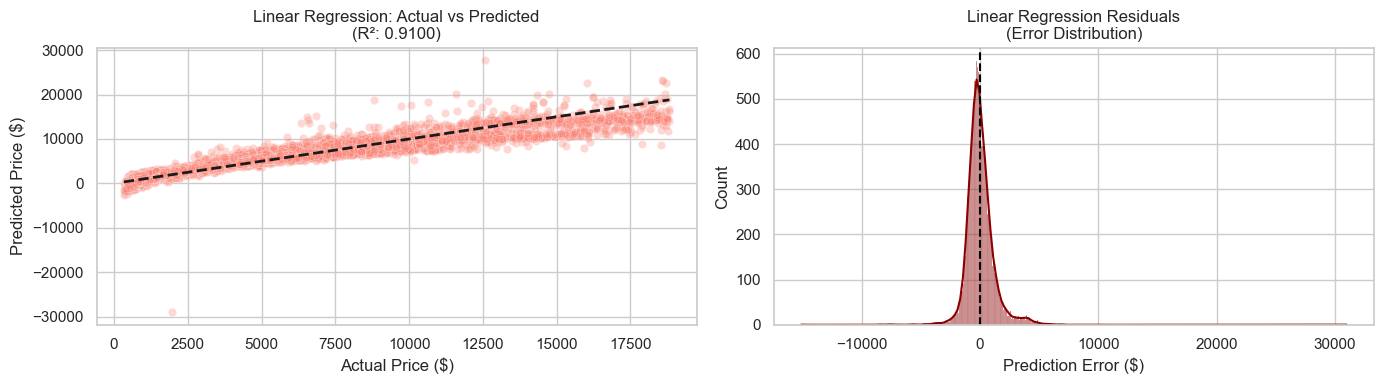

In [ ]:
# Set professional theme
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 4))

# 1. Actual vs Predicted: The "Line of Best Fit"
plt.subplot(1, 2, 1)
# Use 'lr_test_pred' from your model results
sns.scatterplot(x=y_test, y=lr_test_pred, alpha=0.3, color='salmon')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title(f'Linear Regression: Actual vs Predicted\n(R²: {lr_test_r2:.4f})')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')

# 2. Residual Plot: Checking for Heteroscedasticity
plt.subplot(1, 2, 2)
lr_residuals = y_test - lr_test_pred
sns.histplot(lr_residuals, kde=True, color='darkred')
plt.axvline(x=0, color='black', linestyle='--')
plt.title('Linear Regression Residuals\n(Error Distribution)')
plt.xlabel('Prediction Error ($)')

plt.tight_layout()
plt.show()

### Training AdaBoost Regressor model...

In [38]:
print("\n" + "="*50)
print("Training AdaBoost Regressor model...")
print("="*50)

ada = AdaBoostRegressor(n_estimators=100, random_state=42)
ada.fit(X_train, y_train)

# Predictions
ada_train_pred = ada.predict(X_train)
ada_test_pred = ada.predict(X_test)

# Metrics
ada_train_rmse = np.sqrt(mean_squared_error(y_train, ada_train_pred))
ada_test_rmse = np.sqrt(mean_squared_error(y_test, ada_test_pred))
ada_train_mae = mean_absolute_error(y_train, ada_train_pred)
ada_test_mae = mean_absolute_error(y_test, ada_test_pred)
ada_train_r2 = r2_score(y_train, ada_train_pred)
ada_test_r2 = r2_score(y_test, ada_test_pred)

# Print results
print(f"AdaBoost - Training RMSE: {ada_train_rmse:.2f}, Testing RMSE: {ada_test_rmse:.2f}")
print(f"AdaBoost - Training MAE: {ada_train_mae:.2f}, Testing MAE: {ada_test_mae:.2f}")
print(f"AdaBoost - Training R²: {ada_train_r2:.4f}, Testing R²: {ada_test_r2:.4f}")




Training AdaBoost Regressor model...
AdaBoost - Training RMSE: 1350.27, Testing RMSE: 1364.33
AdaBoost - Training MAE: 1114.34, Testing MAE: 1122.37
AdaBoost - Training R²: 0.8851, Testing R²: 0.8839


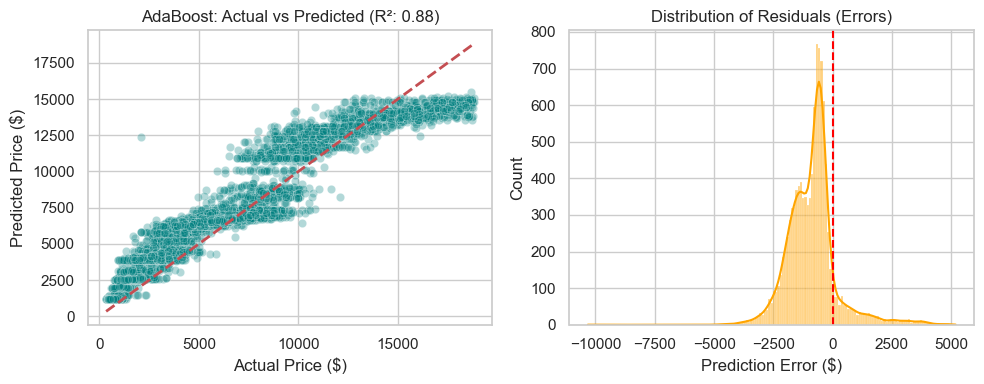

In [ ]:

# Set the style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 4))

# Plot 1: Actual vs Predicted Prices
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=ada_test_pred, alpha=0.3, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'AdaBoost: Actual vs Predicted (R²: {ada_test_r2:.2f})')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')

# Plot 2: Residual Plot (Error Distribution)
plt.subplot(1, 2, 2)
residuals = y_test - ada_test_pred
sns.histplot(residuals, kde=True, color='orange')
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Distribution of Residuals (Errors)')
plt.xlabel('Prediction Error ($)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

### Training Gradient Boosting Model

In [41]:
print("\n" + "="*50)
print("Training Gradient Boosting Model...")
print("="*50)

gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train, y_train)

# Predictions
gb_train_pred = gb.predict(X_train)
gb_test_pred = gb.predict(X_test)

# Metrics
gb_train_rmse = np.sqrt(mean_squared_error(y_train, gb_train_pred))
gb_test_rmse = np.sqrt(mean_squared_error(y_test, gb_test_pred))
gb_train_mae = mean_absolute_error(y_train, gb_train_pred)
gb_test_mae = mean_absolute_error(y_test, gb_test_pred)
gb_train_r2 = r2_score(y_train, gb_train_pred)
gb_test_r2 = r2_score(y_test, gb_test_pred)

# Print result 
print(f"Gradient Boosting - Training RMSE: {gb_train_rmse:.2f}, Testing RMSE: {gb_test_rmse:.2f}")
print(f"Gradient Boosting - Training MAE: {gb_train_mae:.2f}, Testing MAE: {gb_test_mae:.2f}")
print(f"Gradient Boosting - Training R²: {gb_train_r2:.4f}, Testing R²: {gb_test_r2:.4f}")
print("\n" + "="*50)





Training Gradient Boosting Model...
Gradient Boosting - Training RMSE: 594.94, Testing RMSE: 615.19
Gradient Boosting - Training MAE: 334.65, Testing MAE: 340.23
Gradient Boosting - Training R²: 0.9777, Testing R²: 0.9764



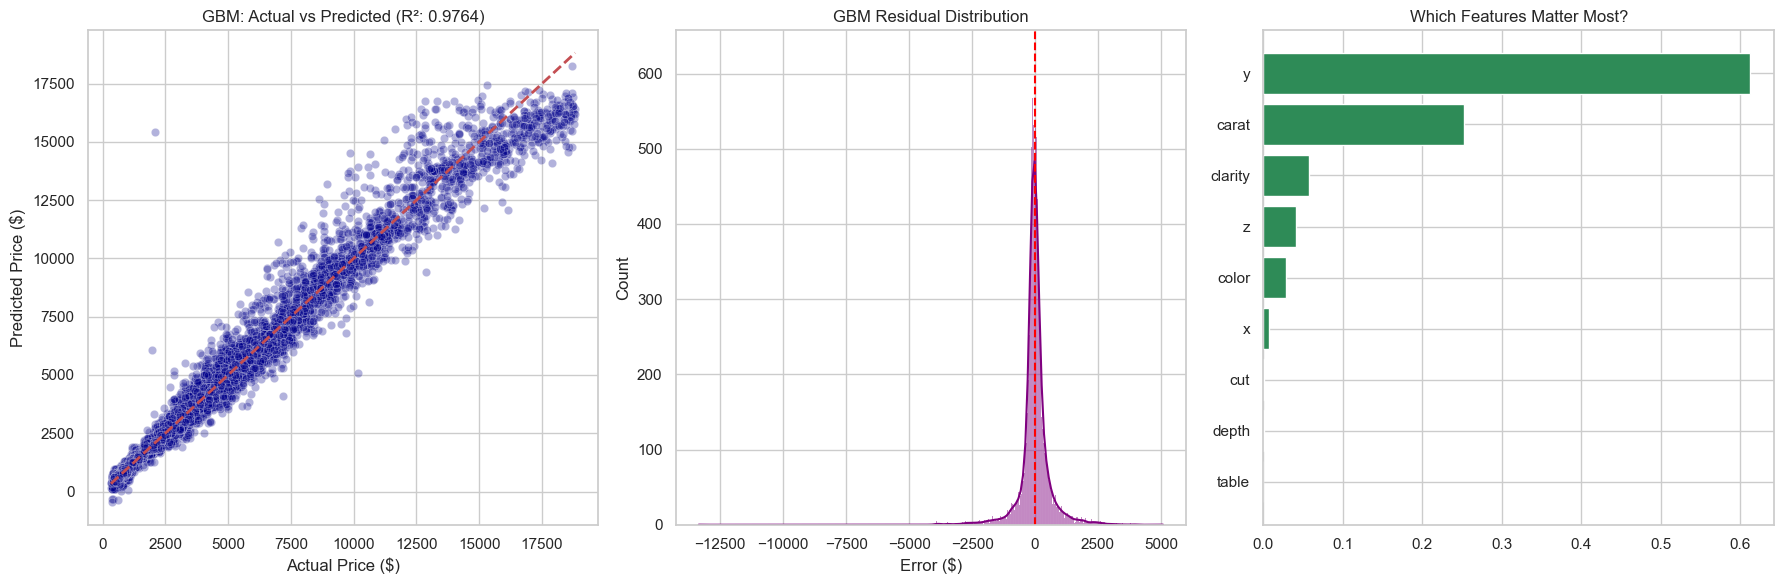

In [44]:
# Set style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 6))

# 1. Actual vs Predicted (The "Success" Plot)
plt.subplot(1, 3, 1)
sns.scatterplot(x=y_test, y=gb_test_pred, alpha=0.3, color='darkblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'GBM: Actual vs Predicted (R²: {gb_test_r2:.4f})')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')

# 2. Residual Distribution (The "Bias Check")
plt.subplot(1, 3, 2)
gb_residuals = y_test - gb_test_pred
sns.histplot(gb_residuals, kde=True, color='purple')
plt.axvline(x=0, color='red', linestyle='--')
plt.title('GBM Residual Distribution')
plt.xlabel('Error ($)')

# 3. Feature Importance (The "Logic" Check)
plt.subplot(1, 3, 3)
importances = gb.feature_importances_
indices = np.argsort(importances)
plt.barh(range(len(indices)), importances[indices], color='seagreen')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.title('Which Features Matter Most?')

plt.tight_layout()
plt.show()

### Traning XGBoost Model... 

In [59]:
print("\n" + "="*50)
print("Training XGBOOST Model...")
print("="*50)

xgb = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
xgb.fit(X_train, y_train)

# Predictions
xgb_train_pred = xgb.predict(X_train)
xgb_test_pred = xgb.predict(X_test)

# Metrics
xgb_train_rmse = np.sqrt(mean_squared_error(y_train, xgb_train_pred))
xgb_test_rmse = np.sqrt(mean_squared_error(y_test, xgb_test_pred))
xgb_train_mae = mean_absolute_error(y_train, xgb_train_pred)
xgb_test_mae = mean_absolute_error(y_test, xgb_test_pred)
xgb_train_r2 = r2_score(y_train, xgb_train_pred)
xgb_test_r2 = r2_score(y_test, xgb_test_pred)

# Print results
print(f"XGBoost - Training RMSE: {xgb_train_rmse:.2f}, Testing RMSE: {xgb_test_rmse:.2f}")
print(f"XGBoost - Training MAE: {xgb_train_mae:.2f}, Testing MAEL: {xgb_test_mae:.2f}")
print(f"XGBoost - Training R²: {xgb_train_r2:.4f}, Testing R²: {xgb_test_r2:.4f}")
print("\n" + "="*50)


Training XGBOOST Model...


XGBoost - Training RMSE: 604.12, Testing RMSE: 618.81
XGBoost - Training MAE: 336.98, Testing MAEL: 340.12
XGBoost - Training R²: 0.9770, Testing R²: 0.9761



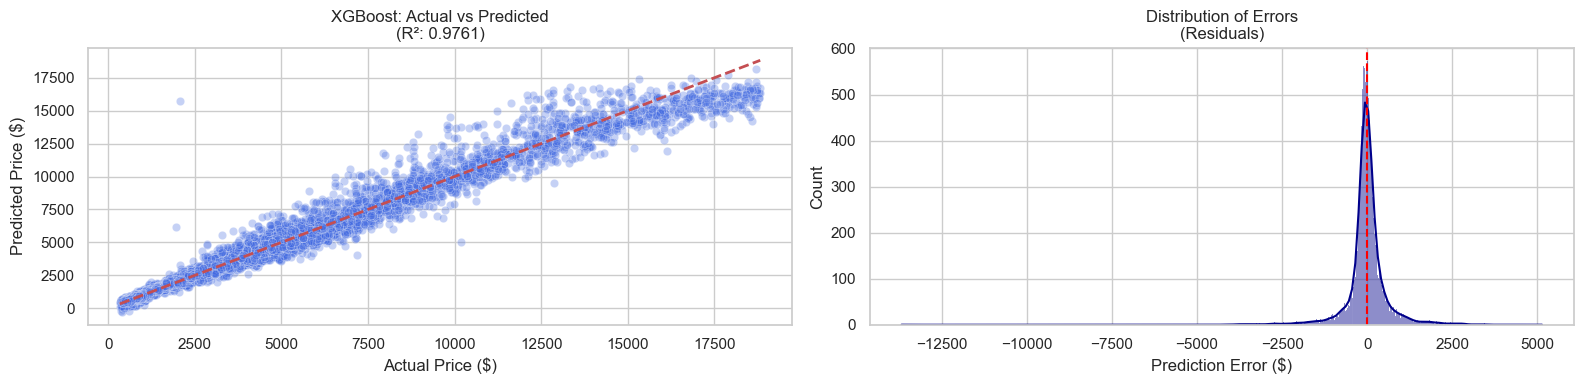

In [72]:
# Set the theme for a clean, academic look
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 4))

# 1. Actual vs Predicted: Checking how well the model "fits" the reality
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=xgb_test_pred, alpha=0.3, color='royalblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'XGBoost: Actual vs Predicted\n(R²: {xgb_test_r2:.4f})')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')

# 2. Residuals: Checking if the errors are random or biased
plt.subplot(1, 2, 2)
xgb_residuals = y_test - xgb_test_pred
sns.histplot(xgb_residuals, kde=True, color='darkblue')
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Distribution of Errors\n(Residuals)')
plt.xlabel('Prediction Error ($)')

plt.tight_layout()
plt.show()

### Comparing all Models


FINAL MODEL COMPARISON
            Model  Train_RMSE  Test_RMSE  Test_MAE  R2_Score  Overfit_Gap
Linear Regression     1226.53    1201.39    790.37      0.91        25.14
         AdaBoost     1350.27    1364.33   1122.37      0.88       -14.06
Gradient Boosting      594.94     615.19    340.23      0.98       -20.25
          XGBoost      604.12     618.81    340.12      0.98       -14.69


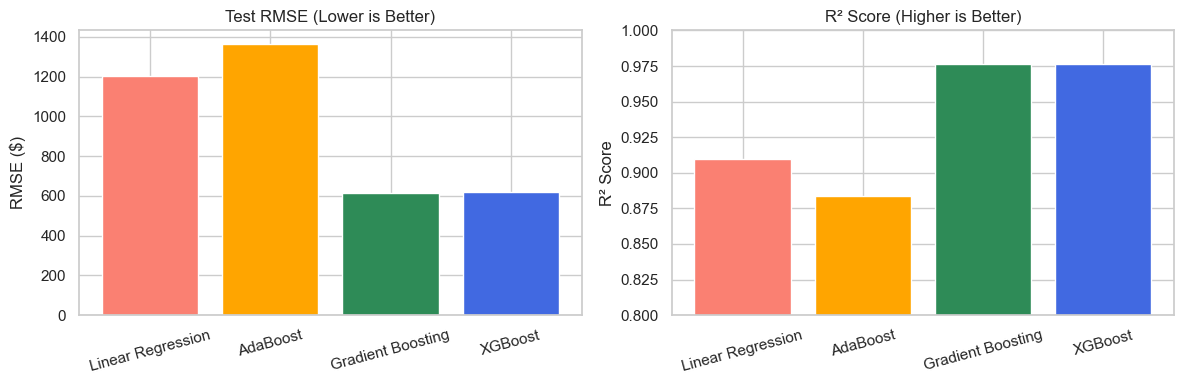

In [89]:
import pandas as pd
import matplotlib.pyplot as plt

# Create the comparison table
# Note: I've updated the variable names to match what we calculated in previous steps
results = pd.DataFrame({
    'Model': ['Linear Regression', 'AdaBoost', 'Gradient Boosting', 'XGBoost'],
    'Train_RMSE': [lr_train_rmse, ada_train_rmse, gb_train_rmse, xgb_train_rmse],
    'Test_RMSE': [lr_test_pred_rmse, ada_test_rmse, gb_test_rmse, xgb_test_rmse],
    'Test_MAE': [lr_test_mae, ada_test_mae, gb_test_mae, xgb_test_mae],
    'R2_Score': [lr_test_r2, ada_test_r2, gb_test_r2, xgb_test_r2],
    'Overfit_Gap': [
        lr_train_rmse - lr_test_pred_rmse, 
        ada_train_rmse - ada_test_rmse, 
        gb_train_rmse - gb_test_rmse, 
        xgb_train_rmse - xgb_test_rmse
    ]
})

print("\n" + "="*80)
print("FINAL MODEL COMPARISON")
print("="*80)
print(results.round(2).to_string(index=False))

# Visualize comparison
plt.figure(figsize=(12, 4))

# Subplot 1: RMSE Comparison
plt.subplot(1, 2, 1)
bars1 = plt.bar(results['Model'], results['Test_RMSE'], color=['salmon', 'orange', 'seagreen', 'royalblue'])
plt.title('Test RMSE (Lower is Better)')
plt.xticks(rotation=15)
plt.ylabel('RMSE ($)')

# Subplot 2: R² Score Comparison
plt.subplot(1, 2, 2)
bars2 = plt.bar(results['Model'], results['R2_Score'], color=['salmon', 'orange', 'seagreen', 'royalblue'])
plt.title('R² Score (Higher is Better)')
plt.xticks(rotation=15)
plt.ylabel('R² Score')
plt.ylim(0.8, 1.0) # Zooming in to see the performance gap clearly

plt.tight_layout()
plt.show()